# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

# План работы

## Этап 1. Подготовка среды и библиотек

In [61]:
from Черепахи import interval_cols
!pip install -q scikit-learn numpy pandas seaborn phik

In [88]:
# Импорт библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import phik

In [63]:
# Глобальная настройка библиотек
mpl.rcParams['figure.constrained_layout.use'] = True

In [64]:
# Random state
RANDOM_STATE=1703

In [65]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv', sep=',', decimal='.')
df.head()

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


## Этап 2. Первичный анализ данных

### 1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  str    
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  str    
 10  preferred_roast           10334 non-null  str    
 11  milk_preference           9782 non-null   str    
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   str    
 14  last_drink_size  

In [67]:
df.describe(include='all')

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
count,10450,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,10192,...,9913.000000,9757.000000,9593.000000,9729.000000,9771,9719.000000,10114,9840.000000,10340,10450.000000
unique,10450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,4,NaN,3,NaN,100,NaN
top,user_00318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,arabica,...,NaN,NaN,NaN,NaN,spring,NaN,android,NaN,geo_2,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6134,...,NaN,NaN,NaN,NaN,2507,NaN,4611,NaN,1629,NaN
mean,NaN,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,NaN,...,0.753052,4.206709,4.022460,1.013362,NaN,14.554584,NaN,0.192480,NaN,0.060191
std,NaN,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,NaN,...,0.431258,0.782212,1.207883,1.010342,NaN,15.308869,NaN,0.394268,NaN,0.237852
min,NaN,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,NaN,...,0.000000,1.415526,-0.897000,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
25%,NaN,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,NaN,...,1.000000,3.675543,3.214157,0.000000,NaN,4.000000,NaN,0.000000,NaN,0.000000
50%,NaN,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,NaN,...,1.000000,4.203555,3.990032,1.000000,NaN,10.000000,NaN,0.000000,NaN,0.000000
75%,NaN,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,NaN,...,1.000000,4.717292,4.845225,2.000000,NaN,20.000000,NaN,0.000000,NaN,0.000000


In [68]:
df['subscription_status'].value_counts()

subscription_status
none       3803
basic      2862
premium    1923
pro         924
Name: count, dtype: int64

In [69]:
df['phone_type'].value_counts()

phone_type
android    4611
ios        4502
web        1001
Name: count, dtype: int64

In [70]:
df['coffee_preference_change'].value_counts()

coffee_preference_change
0.0    7946
1.0    1894
Name: count, dtype: int64

In [71]:
df['seasons'].value_counts()

seasons
spring    2507
autumn    2433
winter    2423
summer    2408
Name: count, dtype: int64

In [72]:
df['churn'].value_counts()

churn
0    9821
1     629
Name: count, dtype: int64

Обзорно можно сделать следующие выводы:
- "идентификатор пользователя" - id пользователя в системе, бесполезен для обучения модели
- "количество дней, прошедших с последнего заказа" - в среднем около 3-4 дней, но ясно есть выбросы у пользователей, которые перестали покупать кофе
- "среднее число заказов в месяц" и "среднее число заказов в неделю" - в среднем один кофе в неделю и 4 кофе в месяц, но есть и постоянные ежедневные покупатели. Признаки коррелируют, возьмем для обучения "среднее число заказов в неделю"
- "средний чек, в рублях" и "медианный чек, в рублях" - медиана в 2 раза меньше среднего, значит есть большое количество выбросов в размерах чека и лучше использовать медиану в обучении модели
- "сумма заказов за последний месяц" и "сумма заказов за последнюю неделю" - в среднем 400 рублей в неделю и 2000 в месяц. Признаки коррелируют, возьмем для обучения "сумма заказов за последнюю неделю"
- "доля заказов со скидкой за последний месяц" - доля варьируется от около нулевой до 0.89. Признак информативный, возьмем для обучения
- "сорт кофе, купленный пользователем в последний раз на момент сбора данных", "предпочитаемый тип обжарки", "предпочитаемый тип молока", "страна происхождения зерна" - категориальные признаки с небольшим количеством значений. Возможна корреляция между любимым кофе покупателя и его заинтересованностью в кофейне, например что-то могут готовить отлично, а что-то не очень качественно
- "отметка о том, пробовал ли пользователь новейшее сезонное меню" - данный признак может указывать на заинтересованность пользователя, возьмем для обучения
- "размер последнего заказа, совершённого на момент сбора данных" - можем предположить, что чем больше объем кофе, тем больше заинтересованность кофе, проанализируем подробнее на этапе выявления корреляций
- "тип подписки пользователя" - пользователь с подпиской явно заинтересован в кофейне больше, чем пользователь без подписки. Что можно сказать и про пользователя с более высоким уровнем подписки
- "сколько раз за неделю пользователь в среднем открывал приложение доставки кофе" - возможно коррелирует с признаком среднее число заказов в неделю", но потенциально может быть полезен в обучении. Проанализируем подробнее на этапе выявления корреляций
- "включены ли у пользователя уведомления" - пользователь с включенными уведомлениями явно больше заинтересован, чем с выключенными
- "средняя оценка последних на момент сбора данных десяти заказов клиента" - пользователь, которого часто что-то не устраивает вероятно уйдет, а в данных минимальный рейтинг около 1, посмотрим на корреляцию этого признака с таргетом чуть позже
- "оценка последнего на момент сбора данных заказа клиента" - пользователь может перестать совершать покупки и после одного неудачного заказа, так что данная оценка может быть информативной
- "сколько раз приложение зависало за последний месяц" - часто зависание приложения, становится раздражающим фактором и легко может привести к оттоку покупателей
- "текущее время года" - стоит оценить корреляцию между временем года и таргетом. Возможно в какой-то период кофейня становится менее привлекательной
- "сколько дней прошло с последнего использования акции или промокода" - активные пользователи акций более вероятно лояльны
- "тип устройства, с которого пользователь чаще всего совершал покупки" - возможна связь с таргетом, если на разных типах устройств приложения отличаются, но может коррелировать с зависаниями приложения
- "менялись ли вкусовые предпочтения пользователя" - изменение вкусовых предпочтений может повлиять на желание покупателя искать новые вкусы вне нашего кафе и повлиять на уход
- "идентификатор региона пользователя" - в данных 100 регионов, лучше всего для кодирования подойдет Target Encoding, но стоит проверить, есть ли заметная корреляция между регионом и таргетом
- "перестал ли пользователь пользоваться сервисом" - таргет, распределение классов не равномерное, доля положительного класса 0.06, важно это учесть при подготовке к обучению модели

### 2. Опишите целевую переменную

Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

In [73]:
df['churn'].value_counts()

churn
0    9821
1     629
Name: count, dtype: int64

Целевая переменная сильно несбалансирована: доля оттока (churn = 1) составляет ~6% (629 из 10450), а основной класс — ~94%.

Это означает:

- модель может быть смещена в сторону предсказания класса 0
- accuracy неинформативна, нужно использовать метрики типа PR-AUC, ROC-AUC, F1

### 3. Опишите признаки

   - Определите, все ли из них важны.
   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

Краткое описание признаков приведенов пункте 2.1

Из всех признаков на данный момент можно точно удалить `user_id`. Он не несет полезной информации относительно таргета и при этом может вызвать переобучение модели

### 4. Обработайте пропущенные значения.
   - Объясните, как они влияют на данные.
   - Выберите стратегию заполнения пропусков.

Пропуски уменьшают объём доступной информации и могут вносить смещение, если возникают не случайно. Они также искажают распределения признаков и требуют обработки, так как большинство моделей не работает с NaN.


Обработка пропусков требует понимания доменной логики: без этого легко исказить данные и потерять важные сигналы. В идеале такие решения принимаются совместно с экспертом предметной области или дата-инженером, который может объяснить природу пропусков (случайные они или информативные).

В данном задании есть лишь общее указание на наличие пропусков, поэтому будем использовать наиболее универсальные и безопасные подходы.

In [74]:
# количество пропусков по столбцам
df.isna().sum(), df.isna().sum().sum()

(user_id                       0
 days_since_last_order       945
 order_frequency_month       600
 order_frequency_week        388
 avg_order_value             583
 median_order_value          831
 total_spent_last_month      294
 total_spent_last_week       944
 discount_usage_rate         397
 last_coffee_type            258
 preferred_roast             116
 milk_preference             668
 seasonal_menu_tried         989
 coffee_bean_origin          682
 last_drink_size             504
 subscription_status         938
 app_opens_per_week          896
 notifications_enabled       537
 review_rating_last_10       693
 review_rating_last_1        857
 app_crashes_last_month      721
 seasons                     679
 days_since_last_promo       731
 phone_type                  336
 coffee_preference_change    610
 geo_location                110
 churn                         0
 dtype: int64,
 np.int64(15307))

In [75]:
#Количество и доля пропусков в данных
df.isna().any(axis=1).sum(), df.isna().any(axis=1).sum() / len(df)

(np.int64(8171), np.float64(0.7819138755980861))

Пропусков большое количество. В ~78% строк есть явный пропуск хотя бы в одном столбце. Всего явных пропусков ~15 тысяч

Стратегия заполнения пропусков:
- Категориальные признаки - введем категорию `unknown`, чтобы сохранить информацию о неизвестных значениях
- Булевы значения - пропуски считаем за отсутствие признака и заполняем нулями
- Остальные столбцы (числовые) - заполнение медианой, устойчивой к выбросам

### 5. Проанализируйте признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.
   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.
   - Определите, есть ли в данных признаки, которые можно удалить.

In [85]:
# Список категориальных признаков
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.difference(['user_id'])
cat_cols

Index(['coffee_bean_origin', 'geo_location', 'last_coffee_type',
       'last_drink_size', 'milk_preference', 'phone_type', 'preferred_roast',
       'seasons', 'subscription_status'],
      dtype='str')

In [86]:
# Количество уникальных значений в категориальных признаках
df[cat_cols].nunique()

coffee_bean_origin       6
geo_location           100
last_coffee_type         3
last_drink_size          3
milk_preference          6
phone_type               3
preferred_roast          3
seasons                  4
subscription_status      4
dtype: int64

Категориальные данные представленные в данных можно и нужно кодировать, потому что модель логистической регрессии работает только с числами. Для кодирования `geo_location` лучше всего подойдет `TargetEncoder`, для остальных `OneHotEncoder`

**Возможные стратегии генерации признаков**

Recency–Frequency (R/F) — сочетание частоты заказов и давности последнего заказа: частые и недавние покупки указывают на лояльность, редкие и давние — на риск оттока

Conversion — отношение количества заказов к числу открытий приложения: показывает, насколько пользователь конвертируется из интереса в покупку

Week vs Month динамика — сравнение активности или трат за неделю и месяц: позволяет выявить снижение или нестабильность поведения

Падение рейтинга — разница между средним рейтингом и последним заказом: сигнал ухудшения пользовательского опыта

Вовлечённость — комбинация активности и использования скидок (частота открытий × доля заказов со скидкой): отражает общий уровень интереса и взаимодействия с сервисом

На данный момент нельзя сказать, что какие-то признаки можно удалить. Признак `user_id` был удален ранее

### 6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.
   - Выберите способ, которым их можно обработать.

Проанализируем выбросы в числовых столбцах

In [78]:
num_cols = df.select_dtypes(include=['number']).columns

Для начала посмотрим на наличие отрицательных значений в столбцах. Если такие есть, то они не соответствуют доменной логике:

In [79]:
neg_counts = (df[num_cols] < 0).sum()
neg_counts[neg_counts > 0], neg_counts.sum()

(order_frequency_week       83
 avg_order_value             2
 median_order_value          2
 total_spent_last_month      2
 total_spent_last_week     171
 review_rating_last_1        6
 dtype: int64,
 np.int64(266))

Таких значений всего 266. Можем удалить строки с такими значениями из данных

Далее построим scatter plot и box plot для визуального анализа разброса признаков. При этом отбросим булевы признаки:

In [80]:
# Функция для построения графиков histplot + boxplot по данным
def graphs_for_allocation(df):
    fig, axes = plt.subplots(
        len(df.columns),
        2,
        figsize=(10,  len(df.columns) * 2)
    )

    for i, col in enumerate(df.columns):
        sns.histplot(
            data=df,
            x=col,
            ax=axes[i][0],
        )

        sns.boxplot(
            data=df,
            x=col,
            ax=axes[i][1],
        )

    fig.set_constrained_layout_pads(h_pad=0.2, hspace=0.2, wspace=0.1)
    plt.show()

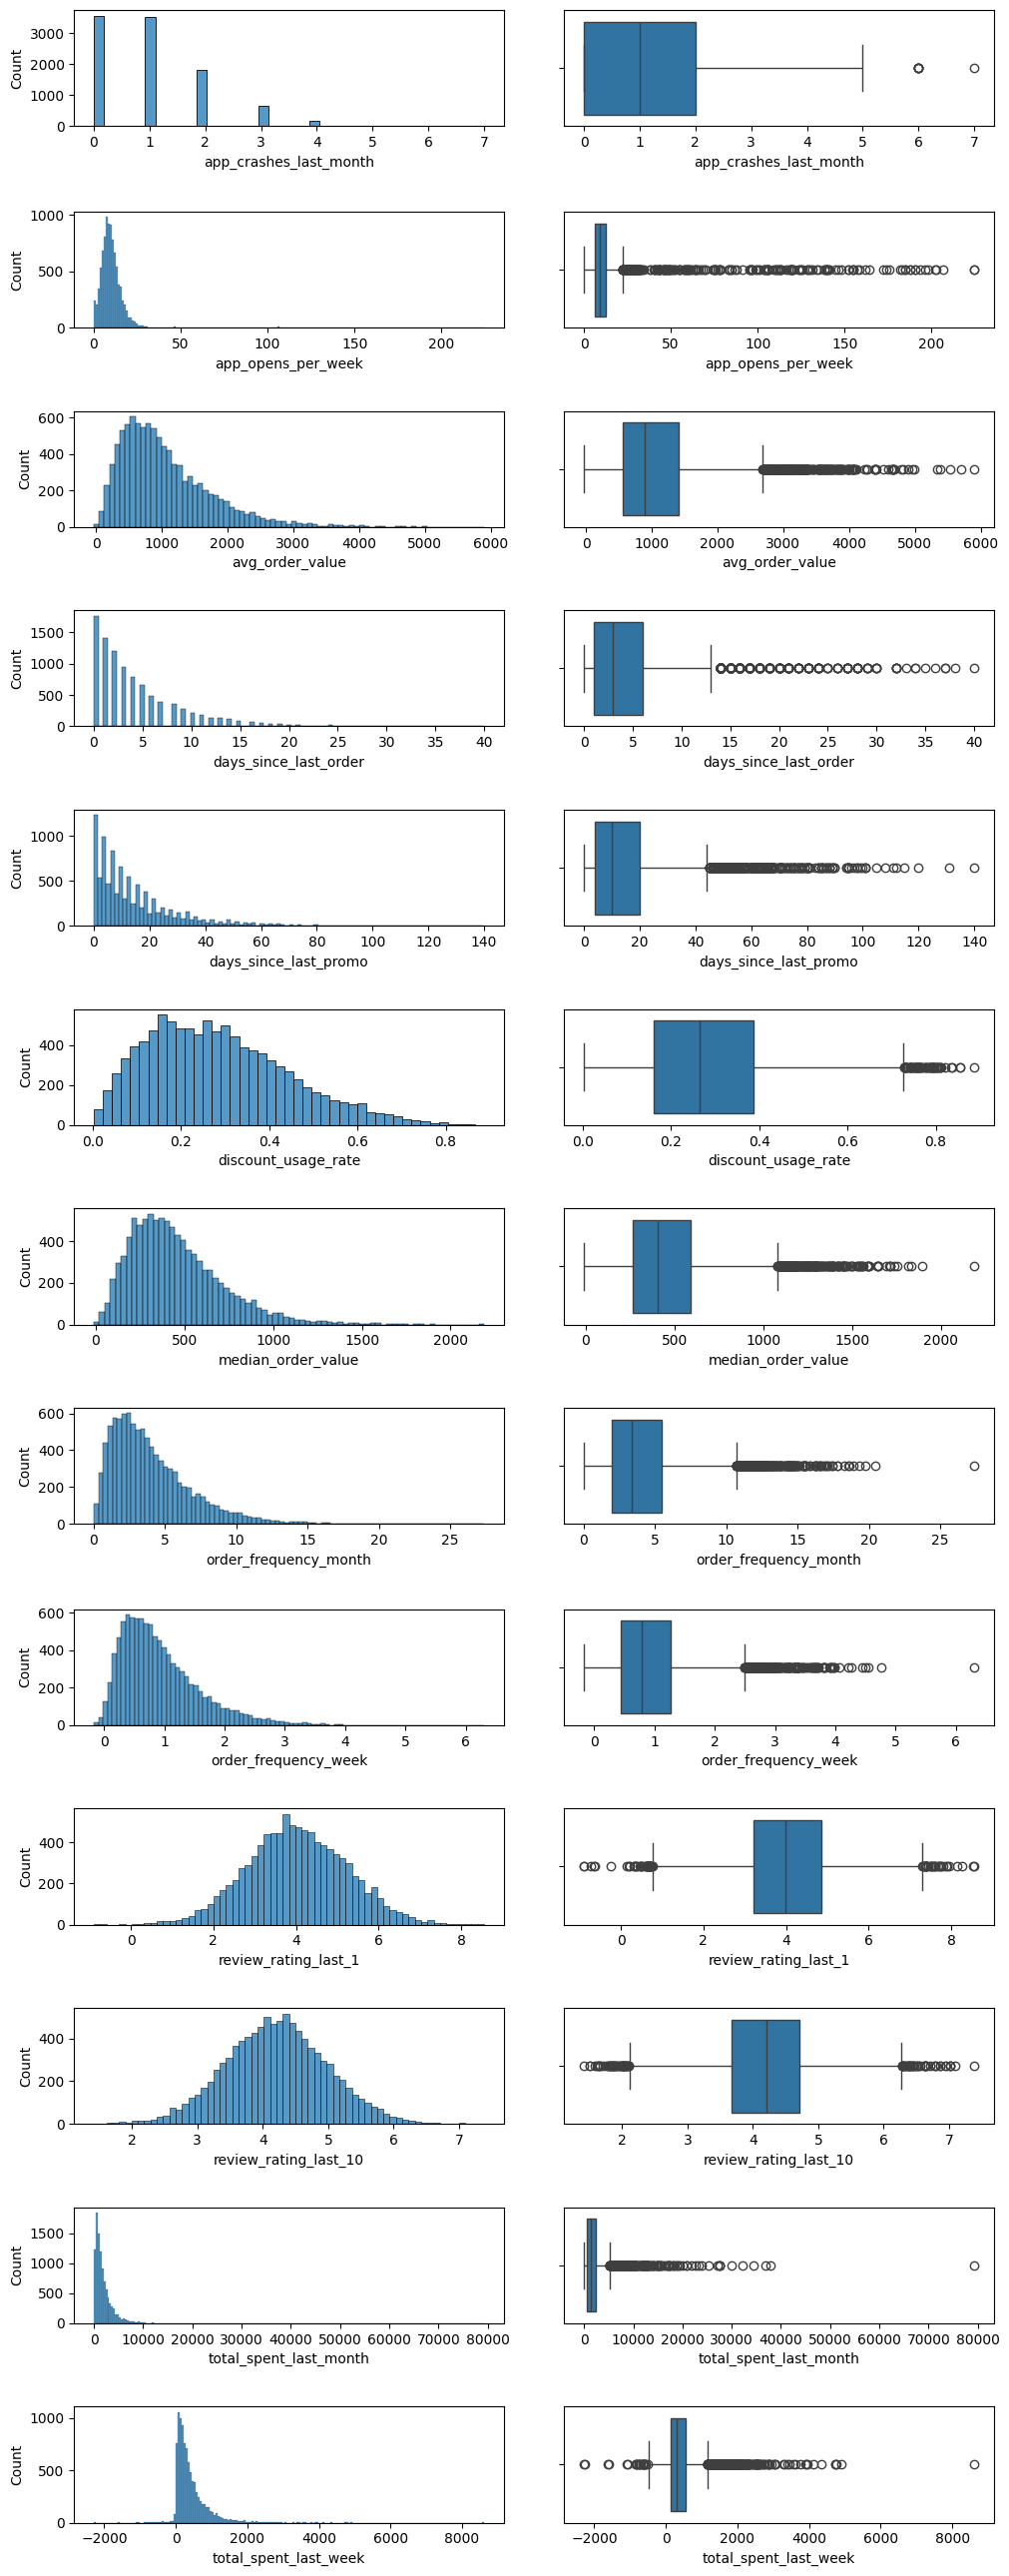

In [81]:
num_cols_without_bool = num_cols.difference(bool_cols)
graphs_for_allocation(df[num_cols_without_bool])

Выбросы разной силы наблюдаются на всех графиках выведенных выше. Посмотрим на количество значений в характеристиках больше 99 перцентиля

In [82]:
# Посчитаем в столбцах `num_cols_without_bool` количество значений больше 99 перцентиля
(df[num_cols_without_bool] > df[num_cols_without_bool].quantile(.99)).sum()

app_crashes_last_month     31
app_opens_per_week         96
avg_order_value            99
days_since_last_order      84
days_since_last_promo      98
discount_usage_rate       101
median_order_value         95
order_frequency_month      99
order_frequency_week      101
review_rating_last_1       96
review_rating_last_10      98
total_spent_last_month    102
total_spent_last_week      96
dtype: int64

In [83]:
# Всего строк со значением в столбцах `num_cols_without_bool` количество значений больше 99 перцентиля
(df[num_cols_without_bool] > df[num_cols_without_bool].quantile(.99)).any(axis=1).sum(), len(df)

(np.int64(917), 10450)

В числовых признаках наблюдаются выбросы: около 10% строк содержат значения выше 99-го перцентиля хотя бы в одном признаке.

Удаление такого объёма данных может привести к потере важной информации и ухудшению качества модели.

Вероятно, часть выбросов отражает реальное поведение пользователей (например, высокая частота заказов или крупные траты), а не ошибки в данных.

Поэтому на данном этапе выбросы не удаляются; вместо этого можно рассмотреть методы их обработки. Применим логарифмирование для столбцов `app_opens_per_week`, `avg_order_value`, `days_since_las_order`, `days_since_last_promo`, `median_order_value`, `order_frequency_month`, `total_spent_last_month`, `total_spent_last_week`

### 7. Посчитайте корреляции между признаками

Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

In [101]:
# Получение phik матрицы. `user_id` убираем из вычислений, так как решили ранее, что его удаляем
cols_to_check = df.columns.difference(['user_id'])
df_phik = df[cols_to_check].phik_matrix(interval_cols=num_cols)

In [113]:
# Функция для построения тепловой карты
def heatmap(df):
    plt.figure(figsize=(20, 15))

    sns.heatmap(
        df,
        cmap="coolwarm",
        vmin=0, vmax=1,
        annot=True, fmt=".2f",
        linewidths=0.5,
        square=True,
        cbar_kws={"shrink": 0.8}
    )

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.title("Phik Correlation Matrix", fontsize=16)
    plt.show()

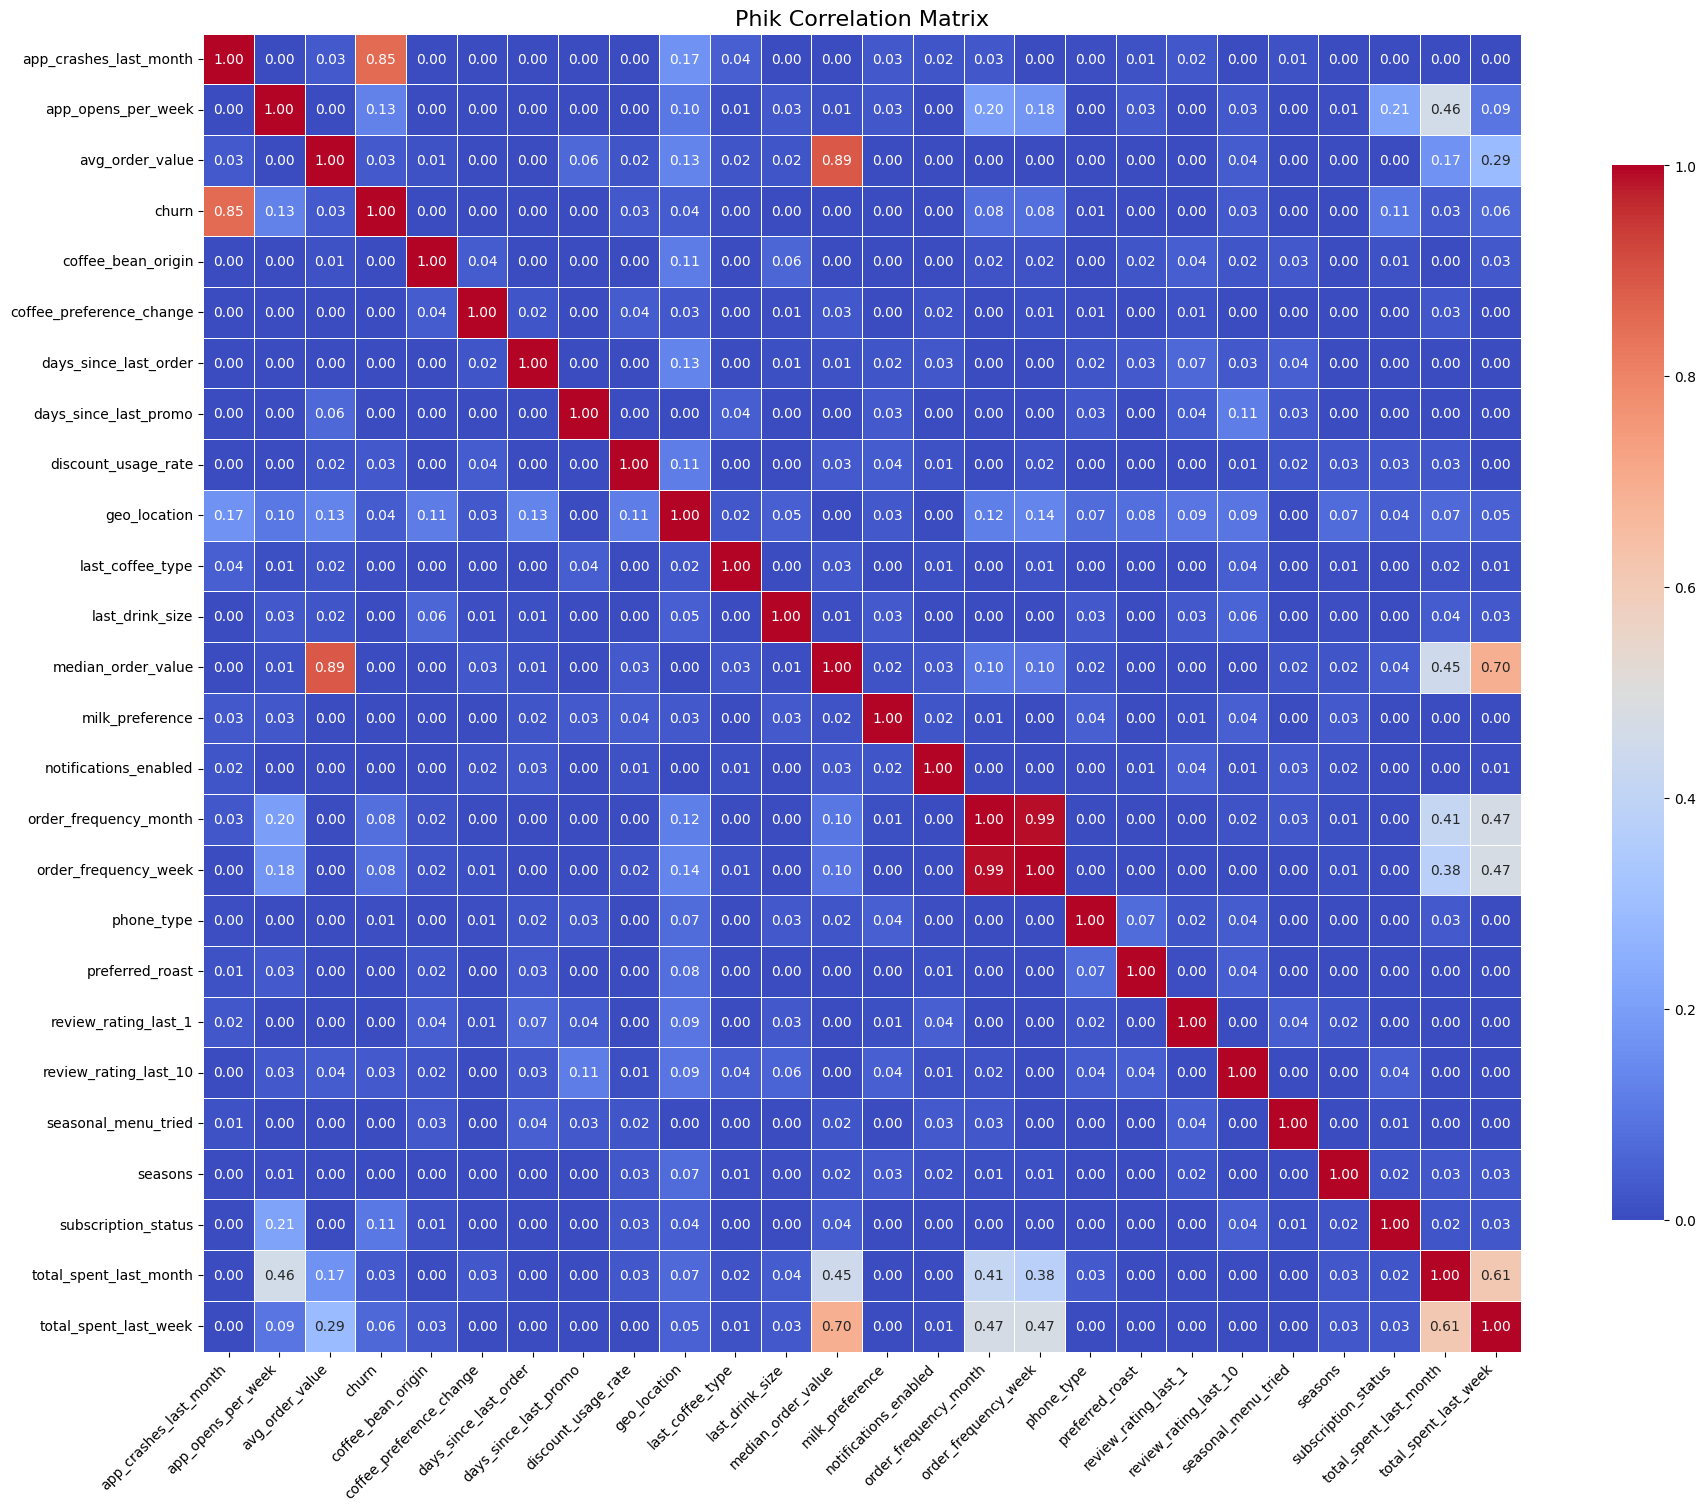

In [114]:
# Построение тепловой карты матрицы корреляций
heatmap(df_phik)

In [110]:
# Функция для получения пар признаков со значением их корреляции
def phik_to_pairs(df_phik):
    s = df_phik.stack()
    s = s[s.index.get_level_values(0) != s.index.get_level_values(1)]
    s = s[s.index.get_level_values(0) < s.index.get_level_values(1)]
    s = s.sort_values(ascending=False)
    return s

In [111]:
# В дополнение к тепловой карте выведем пары с самым большим значением корреляции
phik_to_pairs(df_phik).head(20)

order_frequency_month   order_frequency_week      0.990083
avg_order_value         median_order_value        0.890398
app_crashes_last_month  churn                     0.853545
median_order_value      total_spent_last_week     0.695032
total_spent_last_month  total_spent_last_week     0.609608
order_frequency_week    total_spent_last_week     0.473355
order_frequency_month   total_spent_last_week     0.472064
app_opens_per_week      total_spent_last_month    0.459848
median_order_value      total_spent_last_month    0.446017
order_frequency_month   total_spent_last_month    0.414983
order_frequency_week    total_spent_last_month    0.382369
avg_order_value         total_spent_last_week     0.285857
app_opens_per_week      subscription_status       0.213973
                        order_frequency_month     0.199785
                        order_frequency_week      0.179130
app_crashes_last_month  geo_location              0.170285
avg_order_value         total_spent_last_month    0.1668

**Признаки, которые можно убрать, на основании их корреляции с другими:**
- total_spent_last_month и total_spent_last_week коррелируют с множеством других признаков, но при этом крайне слабо коррелируют с таргетом. Оба **total_spent_last_month и total_spent_last_week** нужно удалить
- order_frequency_month и order_frequency_week очень сильно коррелируют между собой (coef~=.99) - нужно удалить один из признаков. **Удалим order_frequency_week**, так как этот признак хуже коррелирует с таргетом
- avg_order_value и median_order_value очень сильно коррелируют между собой (coef~=.89) - нужно удалить один из признаков. **Удалим median_order_value**, так как этот признак хуже коррелирует с таргетом

In [116]:
# Сохраним все столбцы, которые будут удалены
cols_to_remove = ['user_id', 'total_spent_last_month', 'total_spent_last_week', 'order_frequency_week', 'median_order_value']

Посмотрим повторно на матрицу корреляций без этих признаков:

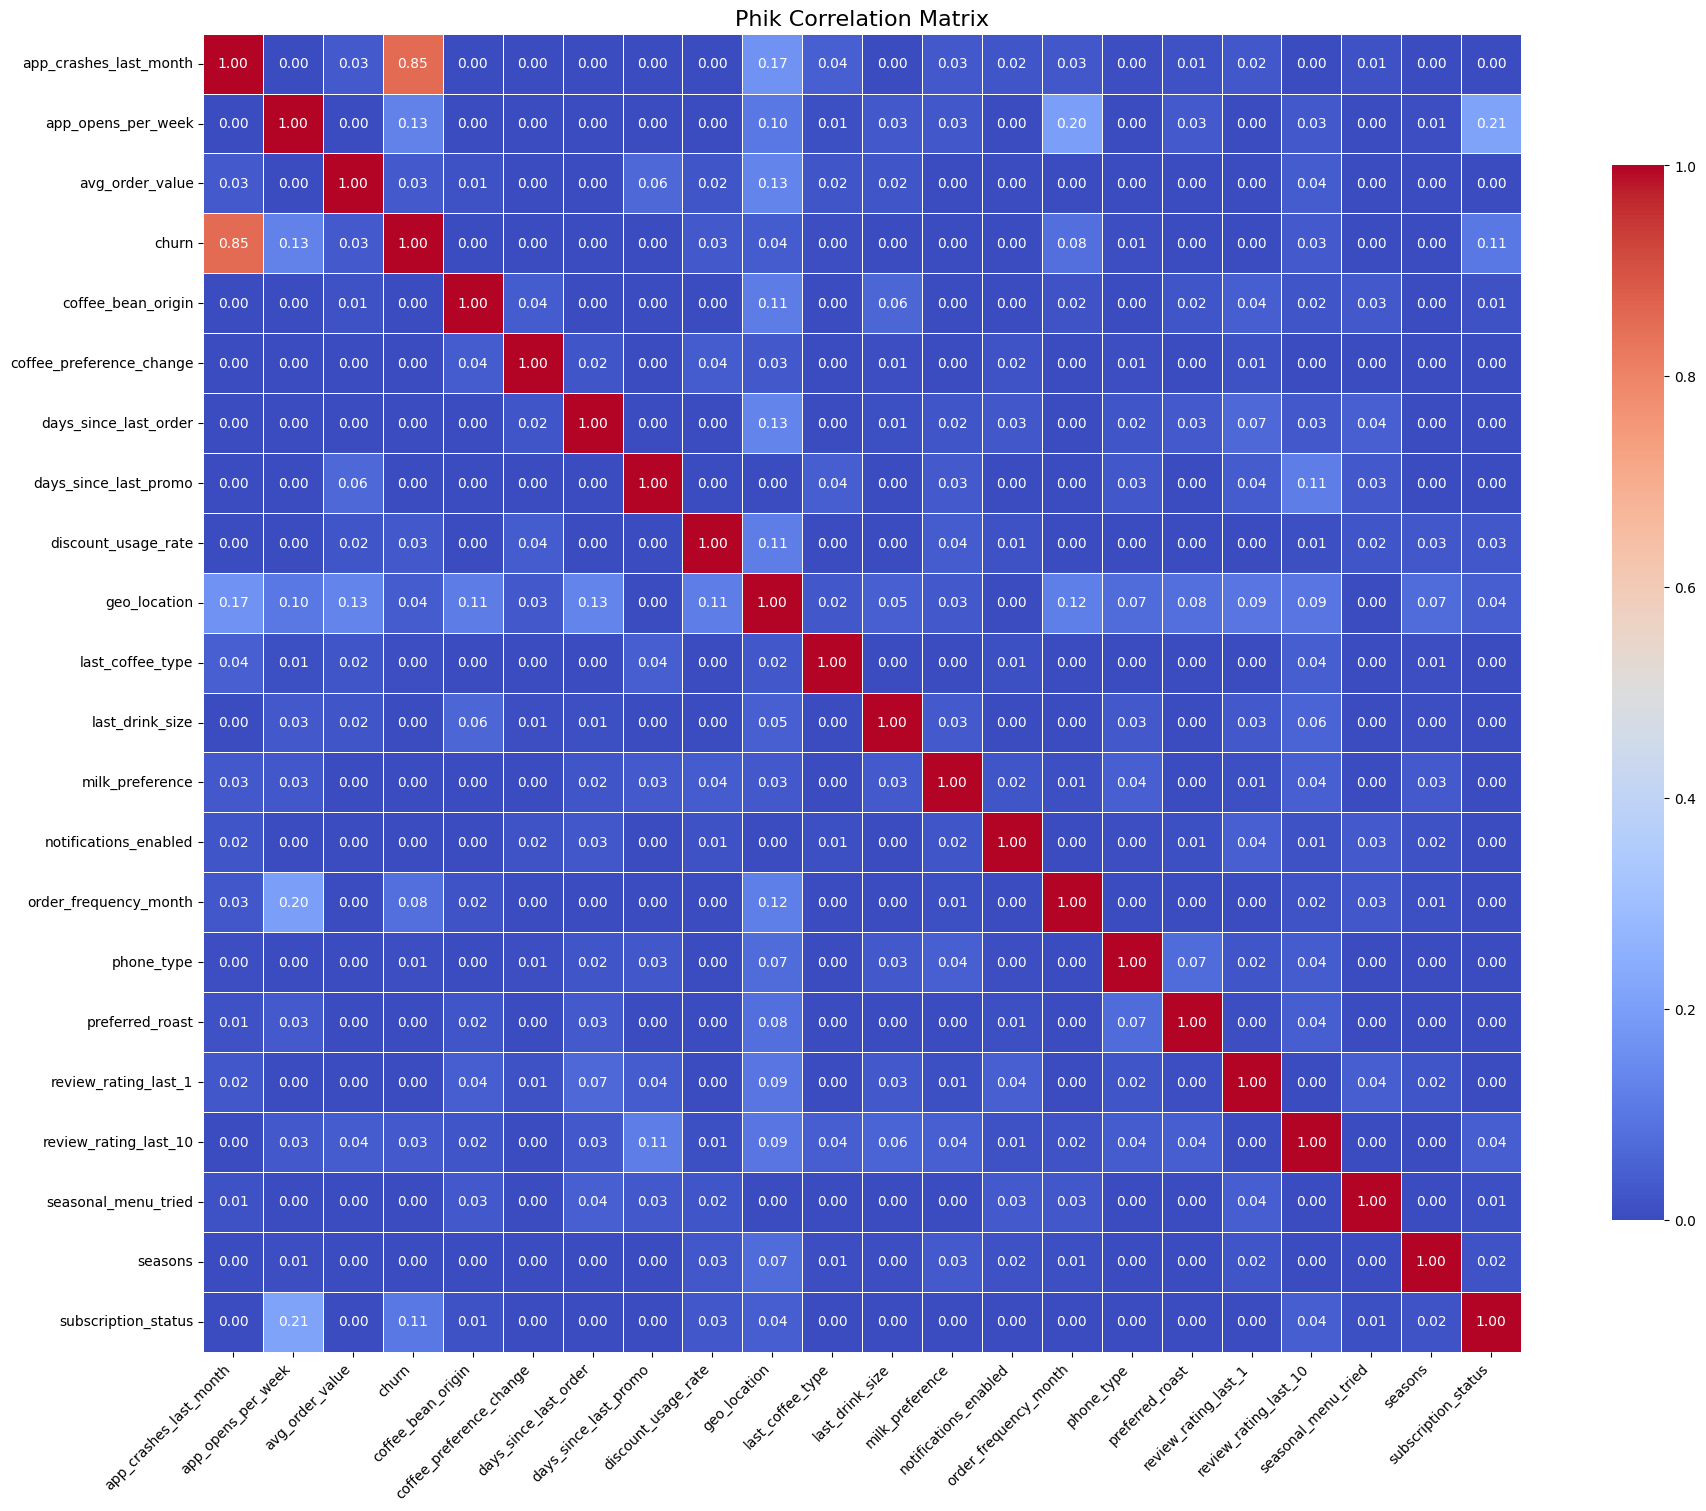

In [118]:
cols_to_check = df.columns.difference(cols_to_remove)
df_phik = df[cols_to_check].phik_matrix(interval_cols=num_cols)
heatmap(df_phik)

Больше сильно коррелирующих признаков не выявлено

### 8. Напишите выводы по результатам исследовательского анализа данных.

В ходе первичного анализа были изучены структура данных, распределение признаков и их потенциальная значимость для задачи прогнозирования оттока пользователей.

Датасет содержит как количественные, так и категориальные признаки, отражающие поведение пользователей, их предпочтения и взаимодействие с сервисом. Целевая переменная характеризуется выраженным дисбалансом классов: доля оттока составляет около 6%, что требует использования устойчивых к дисбалансу метрик качества (например, PR-AUC, ROC-AUC, F1) на последующих этапах моделирования.

Анализ пропущенных значений показал, что значительная часть данных содержит пропуски. Для их обработки выбраны универсальные стратегии: заполнение категориальных признаков значением unknown, числовых — медианой, булевых — нулями. Такой подход позволяет сохранить объём данных и минимизировать искажения распределений.

В процессе анализа признаков были выявлены избыточные и высоко коррелирующие переменные. В частности, удалены идентификатор пользователя (user_id), а также признаки, дублирующие друг друга по смыслу или имеющие высокую взаимную корреляцию. Это позволяет снизить риск мультиколлинеарности и повысить устойчивость модели.

Выбросы присутствуют во многих числовых признаках, однако их природа, вероятно, связана с особенностями поведения пользователей, а не с ошибками данных. В связи с этим было принято решение не удалять такие наблюдения, а учитывать их с помощью преобразований логарифмирования.

Категориальные признаки требуют кодирования для использования в модели: для признаков с большим количеством уникальных значений целесообразно применение Target Encoding, для остальных — One-Hot Encoding.

Также были определены направления для генерации новых признаков, способных повысить качество модели, включая показатели частоты и давности заказов, конверсии, динамики поведения и изменения пользовательского опыта.

В результате проведённого анализа данные признаны пригодными для дальнейшего моделирования после выполнения этапа предобработки.

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.